In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import accuracy_score

In [26]:
from sklearn.datasets import make_blobs

In [27]:
X, y = make_blobs(n_samples=800, n_features=2, centers=5, cluster_std=2, random_state=32)

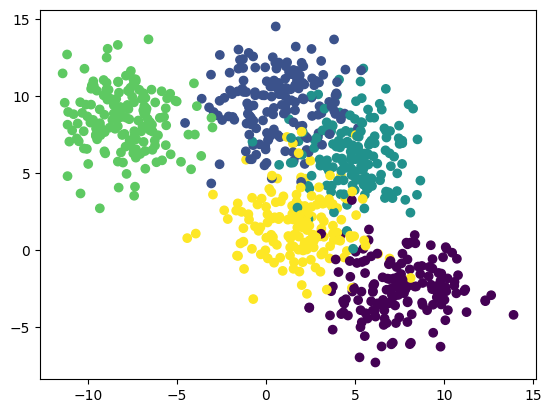

In [28]:
plt.scatter(X[:, 0], X[:, 1], c=y);

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

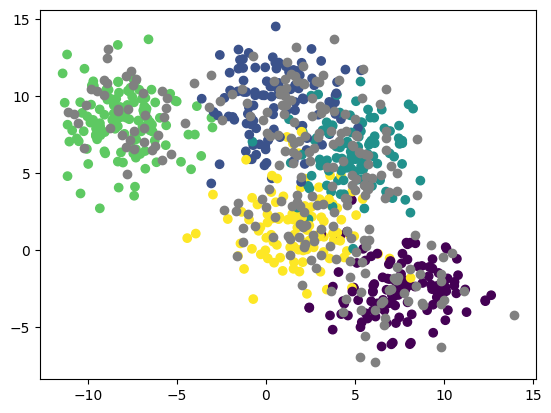

In [30]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.scatter(X_test[:, 0], X_test[:, 1], c='grey');

In [31]:
from sklearn.neighbors import KNeighborsClassifier

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)

In [33]:
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
predictions = knn.predict(X_test)

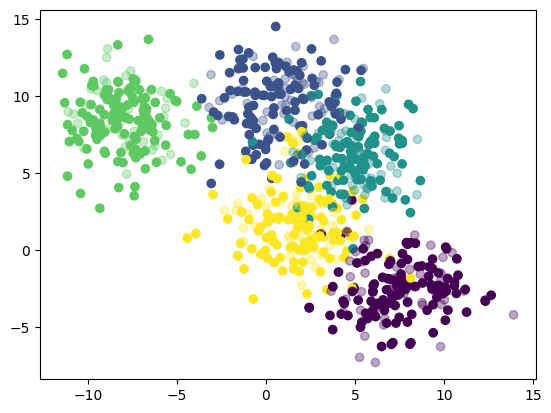

In [35]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.scatter(X_test[:, 0], X_test[:, 1], c=predictions,  alpha=0.35);

### 1. Compute accuracy of the baseline

In [36]:
baseline_accuracy = accuracy_score(y_test, predictions)
print(f"Baseline 5-NN accuracy: {baseline_accuracy * 100:.2f}%")

Baseline 5-NN accuracy: 89.17%


### 2. Complete `predict_proba` method. You are allowed to use only `numpy` library and your code should work for any number of neighbours.

In [37]:
from sklearn.base import BaseEstimator

class KNearest(BaseEstimator):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y)
        self.classes_ = np.unique(self.y)
        self.class_to_index_ = {cls: idx for idx, cls in enumerate(self.classes_)}
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        # pairwise squared Euclidean distances with the use of broadcasting
        diffs = X[:, None, :] - self.X[None, :, :]
        dists_sq = np.sum(diffs * diffs, axis=2)

        # here the code is grabging indices of the closest neighbours
        neighbor_idx = np.argpartition(dists_sq, kth=self.n_neighbors - 1, axis=1)[:, : self.n_neighbors]
        neighbor_labels = self.y[neighbor_idx]

        proba = np.zeros((X.shape[0], self.classes_.size), dtype=np.float64)
        for row_id, labels in enumerate(neighbor_labels):
            mapped = [self.class_to_index_[label] for label in labels]
            counts = np.bincount(mapped, minlength=self.classes_.size)
            proba[row_id] = counts / self.n_neighbors

        return proba

    def predict(self, X):
        proba = self.predict_proba(X)
        winners = np.argmax(proba, axis=1)
        return self.classes_[winners]

In [38]:
custom_knn = KNearest(n_neighbors=5)
custom_knn.fit(X_train, y_train)
custom_predictions = custom_knn.predict(X_test)
print(f'First 10 custom predictions: {custom_predictions[:10]}')

First 10 custom predictions: [0 1 0 0 1 2 3 0 1 4]


### 3. Compare the accuracy of your algorithm with `sklearn` library.

In [39]:
custom_accuracy = accuracy_score(y_test, custom_predictions)
print(f'My NumPy 5-NN accuracy: {custom_accuracy * 100:.2f}%')
print(f'Difference with. sklearn: {(custom_accuracy - baseline_accuracy) * 100:.2f} percentage points')

My NumPy 5-NN accuracy: 89.17%
Difference with. sklearn: 0.00 percentage points


### 4. Compare the speed of your algorithm with `sklearn` library.

In [40]:
custom_t0 = time.perf_counter()
custom_model = KNearest(n_neighbors=5)
custom_model.fit(X_train, y_train)
custom_model.predict(X_test)
custom_runtime = time.perf_counter() - custom_t0

sklearn_t0 = time.perf_counter()
sklearn_model = KNeighborsClassifier(n_neighbors=5)
sklearn_model.fit(X_train, y_train)
sklearn_model.predict(X_test)
sklearn_runtime = time.perf_counter() - sklearn_t0

print(f'My NumPy k-NN runtime: {custom_runtime * 1000:.2f} ms')
print(f'sklearn k-NN runtime: {sklearn_runtime * 1000:.2f} ms')
print(f'Runtime ratio (mine / sklearn): {custom_runtime / sklearn_runtime:.2f}')

My NumPy k-NN runtime: 3.93 ms
sklearn k-NN runtime: 0.98 ms
Runtime ratio (mine / sklearn): 4.01


### 5. Use `KDTree` structure for fast neighbours searching.
Compare accuracy and speed.

In [41]:
from sklearn.neighbors import KDTree

In [42]:
class KNearestWithKDTree(BaseEstimator):
    def __init__(self, n_neighbors=5, leaf_size=30):
        #initialize parameters
        self.leaf_size = leaf_size
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
         # Store the training data and corresponding labels.
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y)
        # Identifing unique classes and build a mapping 
        self.classes_ = np.unique(self.y)
        self.class_to_index_ = {cls: idx for idx, cls in enumerate(self.classes_)}
        # Build the KDTree for fast nearest neighbor search.
        self.tree_ = KDTree(self.X, leaf_size=self.leaf_size)
        return self

    def predict_proba(self, X):
        # Here the code Converts input to numpy array 
        X = np.asarray(X, dtype=np.float64)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        # Search the KDTree to obtain indices of k nearest neighbors of each sample.
        _, indices = self.tree_.query(X, k=self.n_neighbors)
        # Get the labels of these nearest neighbors.
        neighbor_labels = self.y[indices]
        #create an array to hold probabilities
        proba = np.zeros((X.shape[0], self.classes_.size), dtype=np.float64)
        for row_id, labels in enumerate(neighbor_labels):
            mapped = [self.class_to_index_[label] for label in labels]
            counts = np.bincount(mapped, minlength=self.classes_.size)
            proba[row_id] = counts / self.n_neighbors
        return proba

    def predict(self, X):
         # Here the code computes probabilities for all classes using the k nearest neighbors.
        proba = self.predict_proba(X)
        # Selecting the class with the highest proability.
        winners = np.argmax(proba, axis=1)
        return self.classes_[winners]

In [43]:
kdt_t0 = time.perf_counter()
kdt_model = KNearestWithKDTree(n_neighbors=5, leaf_size=30)
kdt_model.fit(X_train, y_train)
kdt_predictions = kdt_model.predict(X_test)
kdt_runtime = time.perf_counter() - kdt_t0

kdt_accuracy = accuracy_score(y_test, kdt_predictions)
print(f'KDTree 5-NN accuracy: {kdt_accuracy * 100:.2f}%')
print(f'KDTree end-to-end runtime: {kdt_runtime * 1000:.2f} ms')
print(f'Speed-up over brute force: {custom_runtime / kdt_runtime:.2f}x faster')

KDTree 5-NN accuracy: 89.17%
KDTree end-to-end runtime: 1.06 ms
Speed-up over brute force: 3.69x faster


### 6. (optional) Implement `KDTree`
If you have time and desire, you can try to implement `KDTree` algorithm.
Compare accuracy and speed.

In [44]:
class KDTreeOwn:
    def __init__(self, X, leaf_size=30):
        """
        build tree
        """
        pass

    def query(self, X, k=1):
        """
        query the tree for the k nearest neighbors
        """
        pass

In [45]:
class KNearestWithKDTreeOwn(BaseEstimator):
    def __init__(self, n_neighbors=5, leaf_size=30):
        self.leaf_size = leaf_size
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict_proba(self, X):
        """
        return probability for each data point of belonging to each cluster
        return N x M matrix prob, where N is number of test samples and M is number of unique classes
        and prob_{ij} — probability for x_i of belonging to j cluster
        """
        n_classes = np.unique(y).size
        return np.zeros((X.shape[0], n_classes))


    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)